Calculando 10000 dígitos de sqrt(2)...


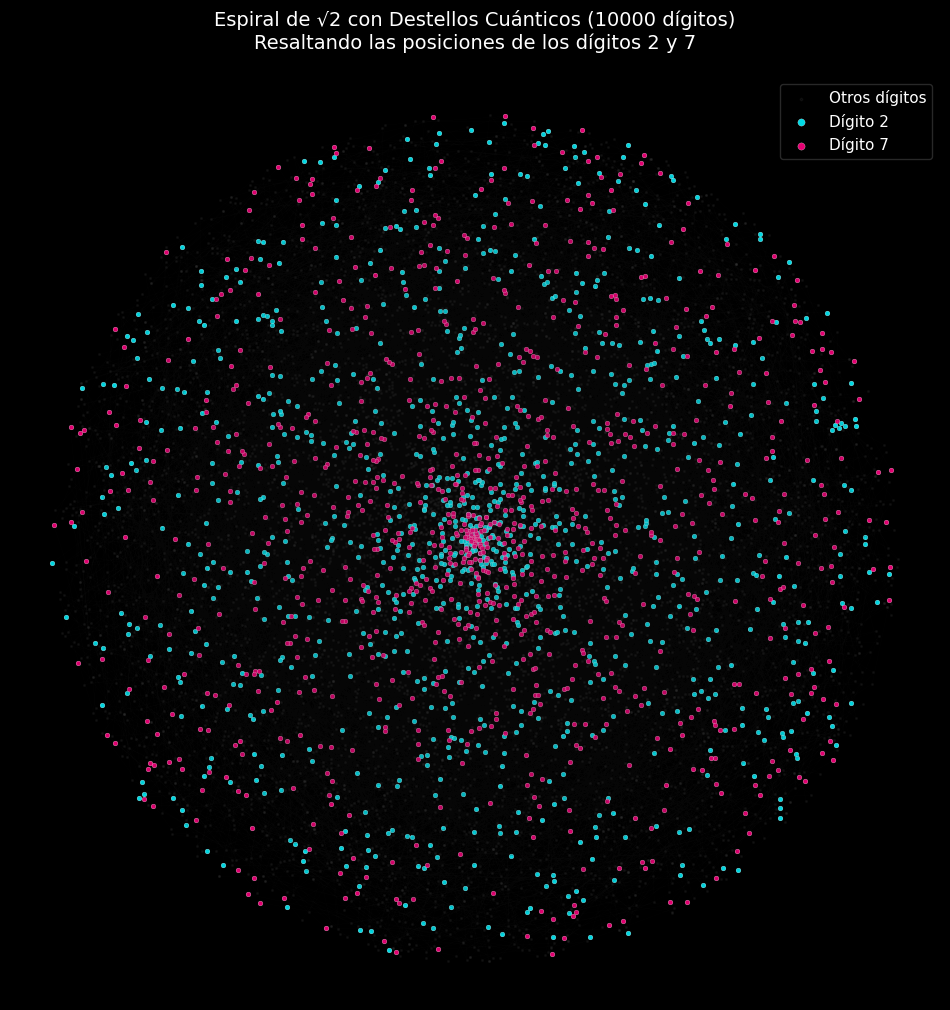

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpmath import mp

# --- CONFIGURACIÓN ---
CANTIDAD_DIGITOS = 10000
mp.dps = CANTIDAD_DIGITOS + 5

print(f"Calculando {CANTIDAD_DIGITOS} dígitos de sqrt(2)...")

# Obtener los dígitos limpios
sqrt2_str = str(mp.sqrt(2)).replace('.', '')
digitos_str = sqrt2_str[:CANTIDAD_DIGITOS]
digitos = np.array([int(d) for d in digitos_str])

# --- LÓGICA DE ESPIRAL ACUMULATIVA ---
r = np.arange(CANTIDAD_DIGITOS)
theta = np.cumsum(digitos) - digitos

x = r * np.cos(theta)
y = r * np.sin(theta)

# --- MÁSCARAS PARA RESALTAR LOS DÍGITOS 2 Y 7 ---
es_dos = (digitos == 2)
es_siete = (digitos == 7)
otros_digitos = ~(es_dos | es_siete)

# --- VISUALIZACIÓN ---
plt.figure(figsize=(12, 12), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# 1. Dibujar la línea de la espiral muy sutil de fondo
plt.plot(x, y, color='#222222', linewidth=0.15, alpha=0.2)

# 2. Dibujar todos los demás dígitos (0,1,3,4,5,6,8,9) muy pequeños y opacos
plt.scatter(x[otros_digitos], y[otros_digitos],
            color='#444444', s=1.5, alpha=0.15, label='Otros dígitos')

# 3. DESTACAR EL DÍGITO 2 (Cian Eléctrico)
plt.scatter(x[es_dos], y[es_dos],
            color='#00f3ff', s=12, alpha=0.9,
            edgecolors='white', linewidths=0.2, label='Dígito 2')

# 4. DESTACAR EL DÍGITO 7 (Fucsia Neón)
plt.scatter(x[es_siete], y[es_siete],
            color='#ff007f', s=12, alpha=0.9,
            edgecolors='white', linewidths=0.2, label='Dígito 7')

# Estética y títulos
plt.title(f"Espiral de √2 con Destellos Cuánticos ({CANTIDAD_DIGITOS} dígitos)\nResaltando las posiciones de los dígitos 2 y 7",
          color='white', fontsize=14, pad=20)
plt.axis('equal')
plt.axis('off')

# Leyenda personalizada para entender el gráfico
plt.legend(facecolor='black', edgecolor='#333333', loc='upper right',
           fontsize=11, labelcolor='white', markerscale=1.5)

plt.show()
